# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
import math

import numpy as np
import pandas as pd
import re
import sklearn.metrics as metrics
from sklearn.dummy import DummyClassifier
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8')

In [3]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [4]:

df_reviews = pd.read_csv('/Users/tjscott23/Documents/NLP/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})
df_reviews.head()


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [5]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [6]:
df_reviews.describe()

,start_year,is_adult,average_rating,votes,rating,pos,idx
count,47331.000000,47331.000000,47329.000000,47329.0,47331.000000,47331.000000,47331.000000
mean,1989.631235,0.001732,5.998278,25562.917323,5.484608,0.498954,6279.697999
std,19.600364,0.041587,1.494289,83670.039163,3.473109,0.500004,3605.702545
min,1894.000000,0.000000,1.400000,9.0,1.000000,0.000000,0.000000
25%,1982.000000,0.000000,5.100000,827.0,2.000000,0.000000,3162.000000
50%,1998.000000,0.000000,6.300000,3197.0,4.000000,0.000000,6299.000000
75%,2004.000000,0.000000,7.100000,13974.0,9.000000,1.000000,9412.000000
max,2010.000000,1.000000,9.700000,1739448.0,10.000000,1.000000,12499.000000


In [7]:
df_reviews.duplicated().sum()

np.int64(0)

In [8]:

df_reviews = df_reviews.dropna()
df_reviews.info()


<class 'pandas.core.frame.DataFrame'>
Index: 47329 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47329 non-null  object 
 1   title_type       47329 non-null  object 
 2   primary_title    47329 non-null  object 
 3   original_title   47329 non-null  object 
 4   start_year       47329 non-null  int64  
 5   end_year         47329 non-null  object 
 6   runtime_minutes  47329 non-null  object 
 7   is_adult         47329 non-null  int64  
 8   genres           47329 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47329 non-null  object 
 12  rating           47329 non-null  int64  
 13  sp               47329 non-null  object 
 14  pos              47329 non-null  int64  
 15  ds_part          47329 non-null  object 
 16  idx              47329 non-null  int64  
dtypes: Int64(1), floa

## Data Preparation

In [9]:
df_reviews['end_year'].value_counts().head()

end_year
\N      45050
2007      225
2008      190
2006      140
2009      130
Name: count, dtype: int64

In [10]:
df_reviews['idx'].value_counts().head()

idx
8335    4
2310    4
2318    4
2319    4
2321    4
Name: count, dtype: int64

In [11]:
df_reviews['sp'].value_counts().head()

sp
neg    23715
pos    23614
Name: count, dtype: int64

In [12]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23614
Name: count, dtype: int64

In [13]:

missing = r'^\s*(/N|\\N|N|NA|NaN|null|none)?\s*$'
df_reviews['end_year'] = df_reviews['end_year'].replace(missing, pd.NA, regex=True)

df_reviews['end_year'] = df_reviews['end_year'].fillna(df_reviews['start_year'])


In [14]:
df_reviews.head(3)

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,1971,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,1971,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,2002,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489


In [15]:

df_reviews = df_reviews.drop('sp', axis = 1)



In [16]:
df_reviews['runtime_minutes'] = df_reviews['runtime_minutes'].replace(missing, pd.NA, regex=True)

df_reviews['runtime_minutes'] = pd.to_numeric(df_reviews['runtime_minutes'], errors='coerce')

df_reviews['runtime_minutes'] = df_reviews.groupby('title_type')['runtime_minutes']\
    .transform(lambda x: x.fillna(x.mean()))

In [17]:

df_reviews['end_year'] = df_reviews['end_year'].astype('int64')
df_reviews['runtime_minutes'] = df_reviews['runtime_minutes'].astype('int64')


In [18]:
df_reviews.dtypes

tconst              object
title_type          object
primary_title       object
original_title      object
start_year           int64
end_year             int64
runtime_minutes      int64
is_adult             int64
genres              object
average_rating     float64
votes                Int64
review              object
rating               int64
pos                  int64
ds_part             object
idx                  int64
dtype: object

In [19]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47329 entries, 0 to 47330
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47329 non-null  object 
 1   title_type       47329 non-null  object 
 2   primary_title    47329 non-null  object 
 3   original_title   47329 non-null  object 
 4   start_year       47329 non-null  int64  
 5   end_year         47329 non-null  int64  
 6   runtime_minutes  47329 non-null  int64  
 7   is_adult         47329 non-null  int64  
 8   genres           47329 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47329 non-null  object 
 12  rating           47329 non-null  int64  
 13  pos              47329 non-null  int64  
 14  ds_part          47329 non-null  object 
 15  idx              47329 non-null  int64  
dtypes: Int64(1), float64(1), int64(7), object(7)
memory usage: 6.2+

## EDA

Let's check the number of movies and reviews over years.

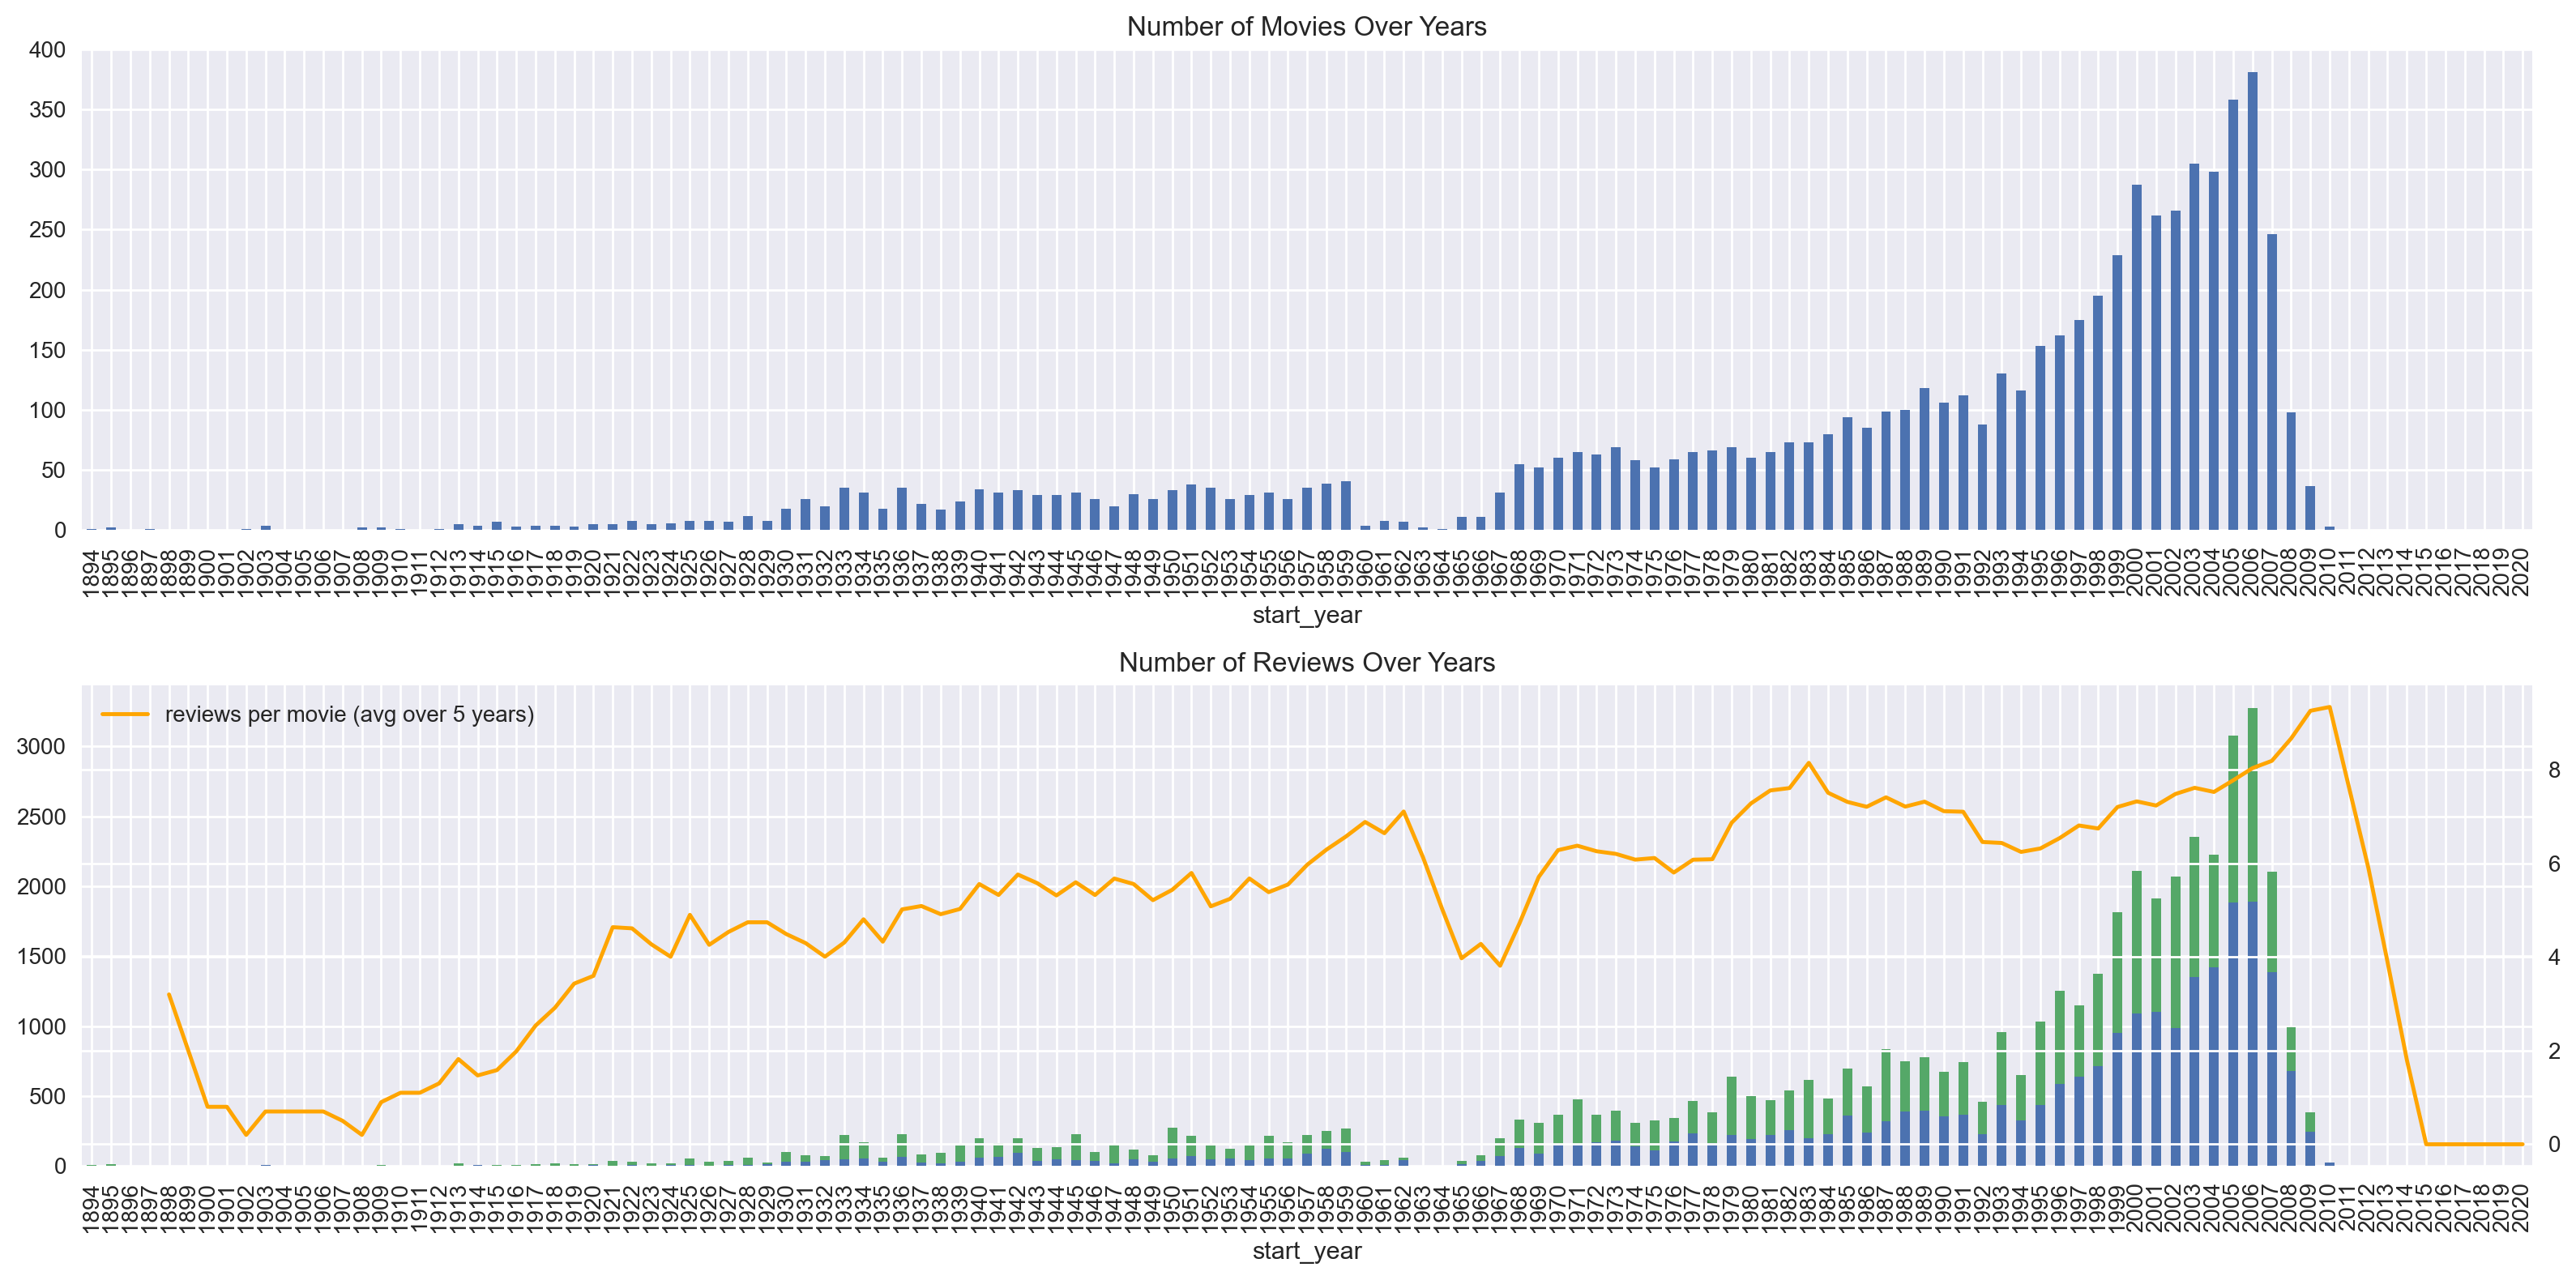

In [20]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


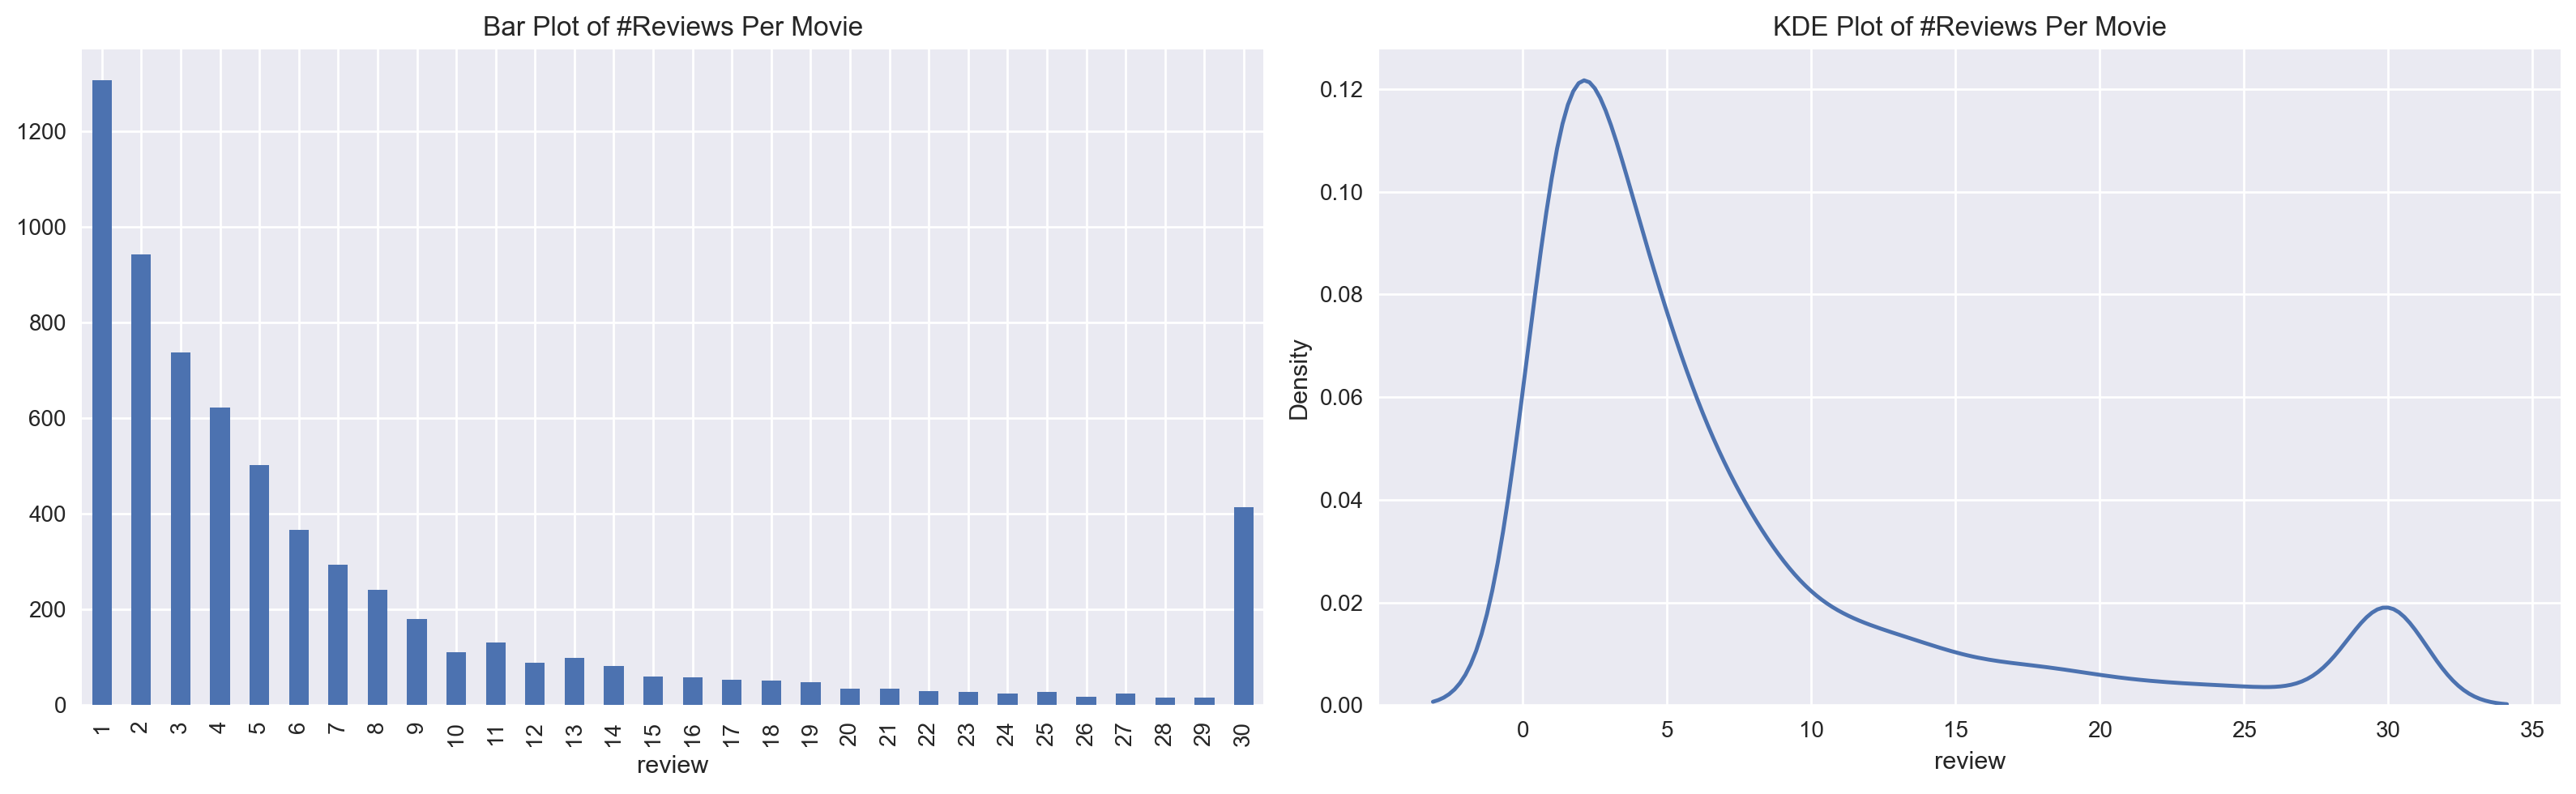

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [22]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23614
Name: count, dtype: int64

There 

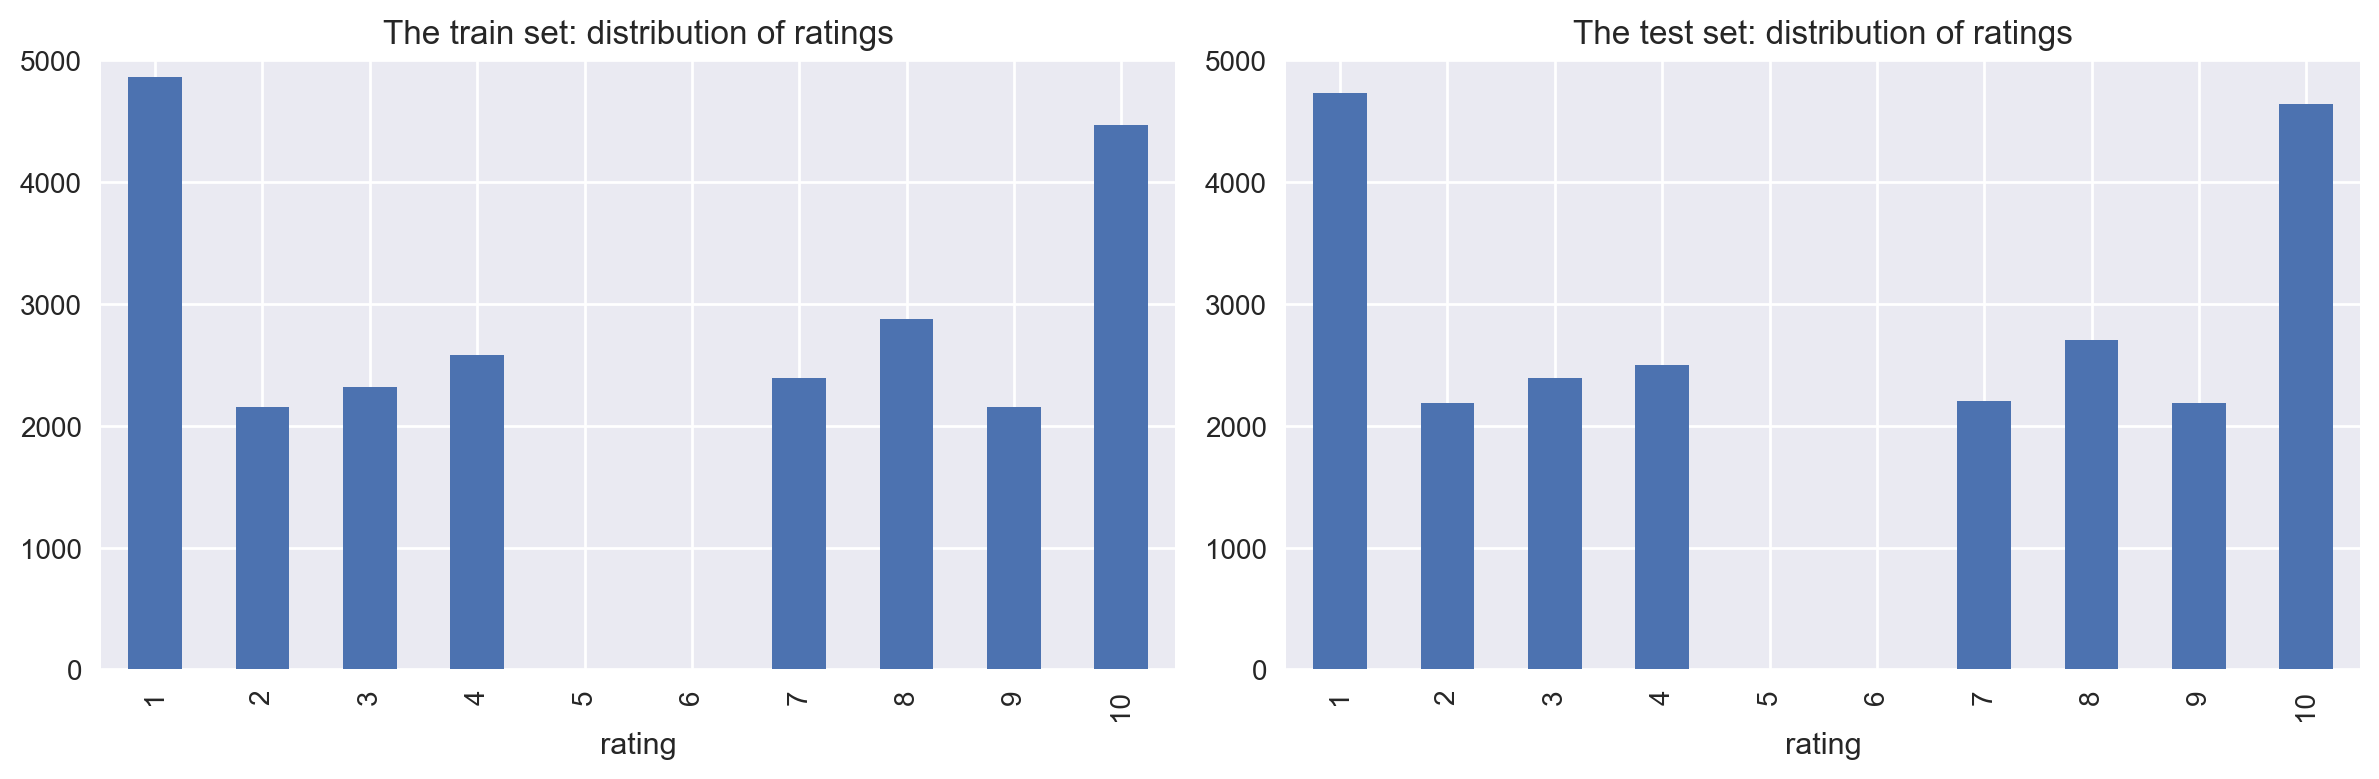

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Distribution of negative and positive reviews over the years for two parts of the dataset

/var/folders/fm/r_9q2fss3pgfdw_nvjhdcd680000gp/T/ipykernel_4771/2564148758.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/var/folders/fm/r_9q2fss3pgfdw_nvjhdcd680000gp/T/ipykernel_4771/2564148758.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.1

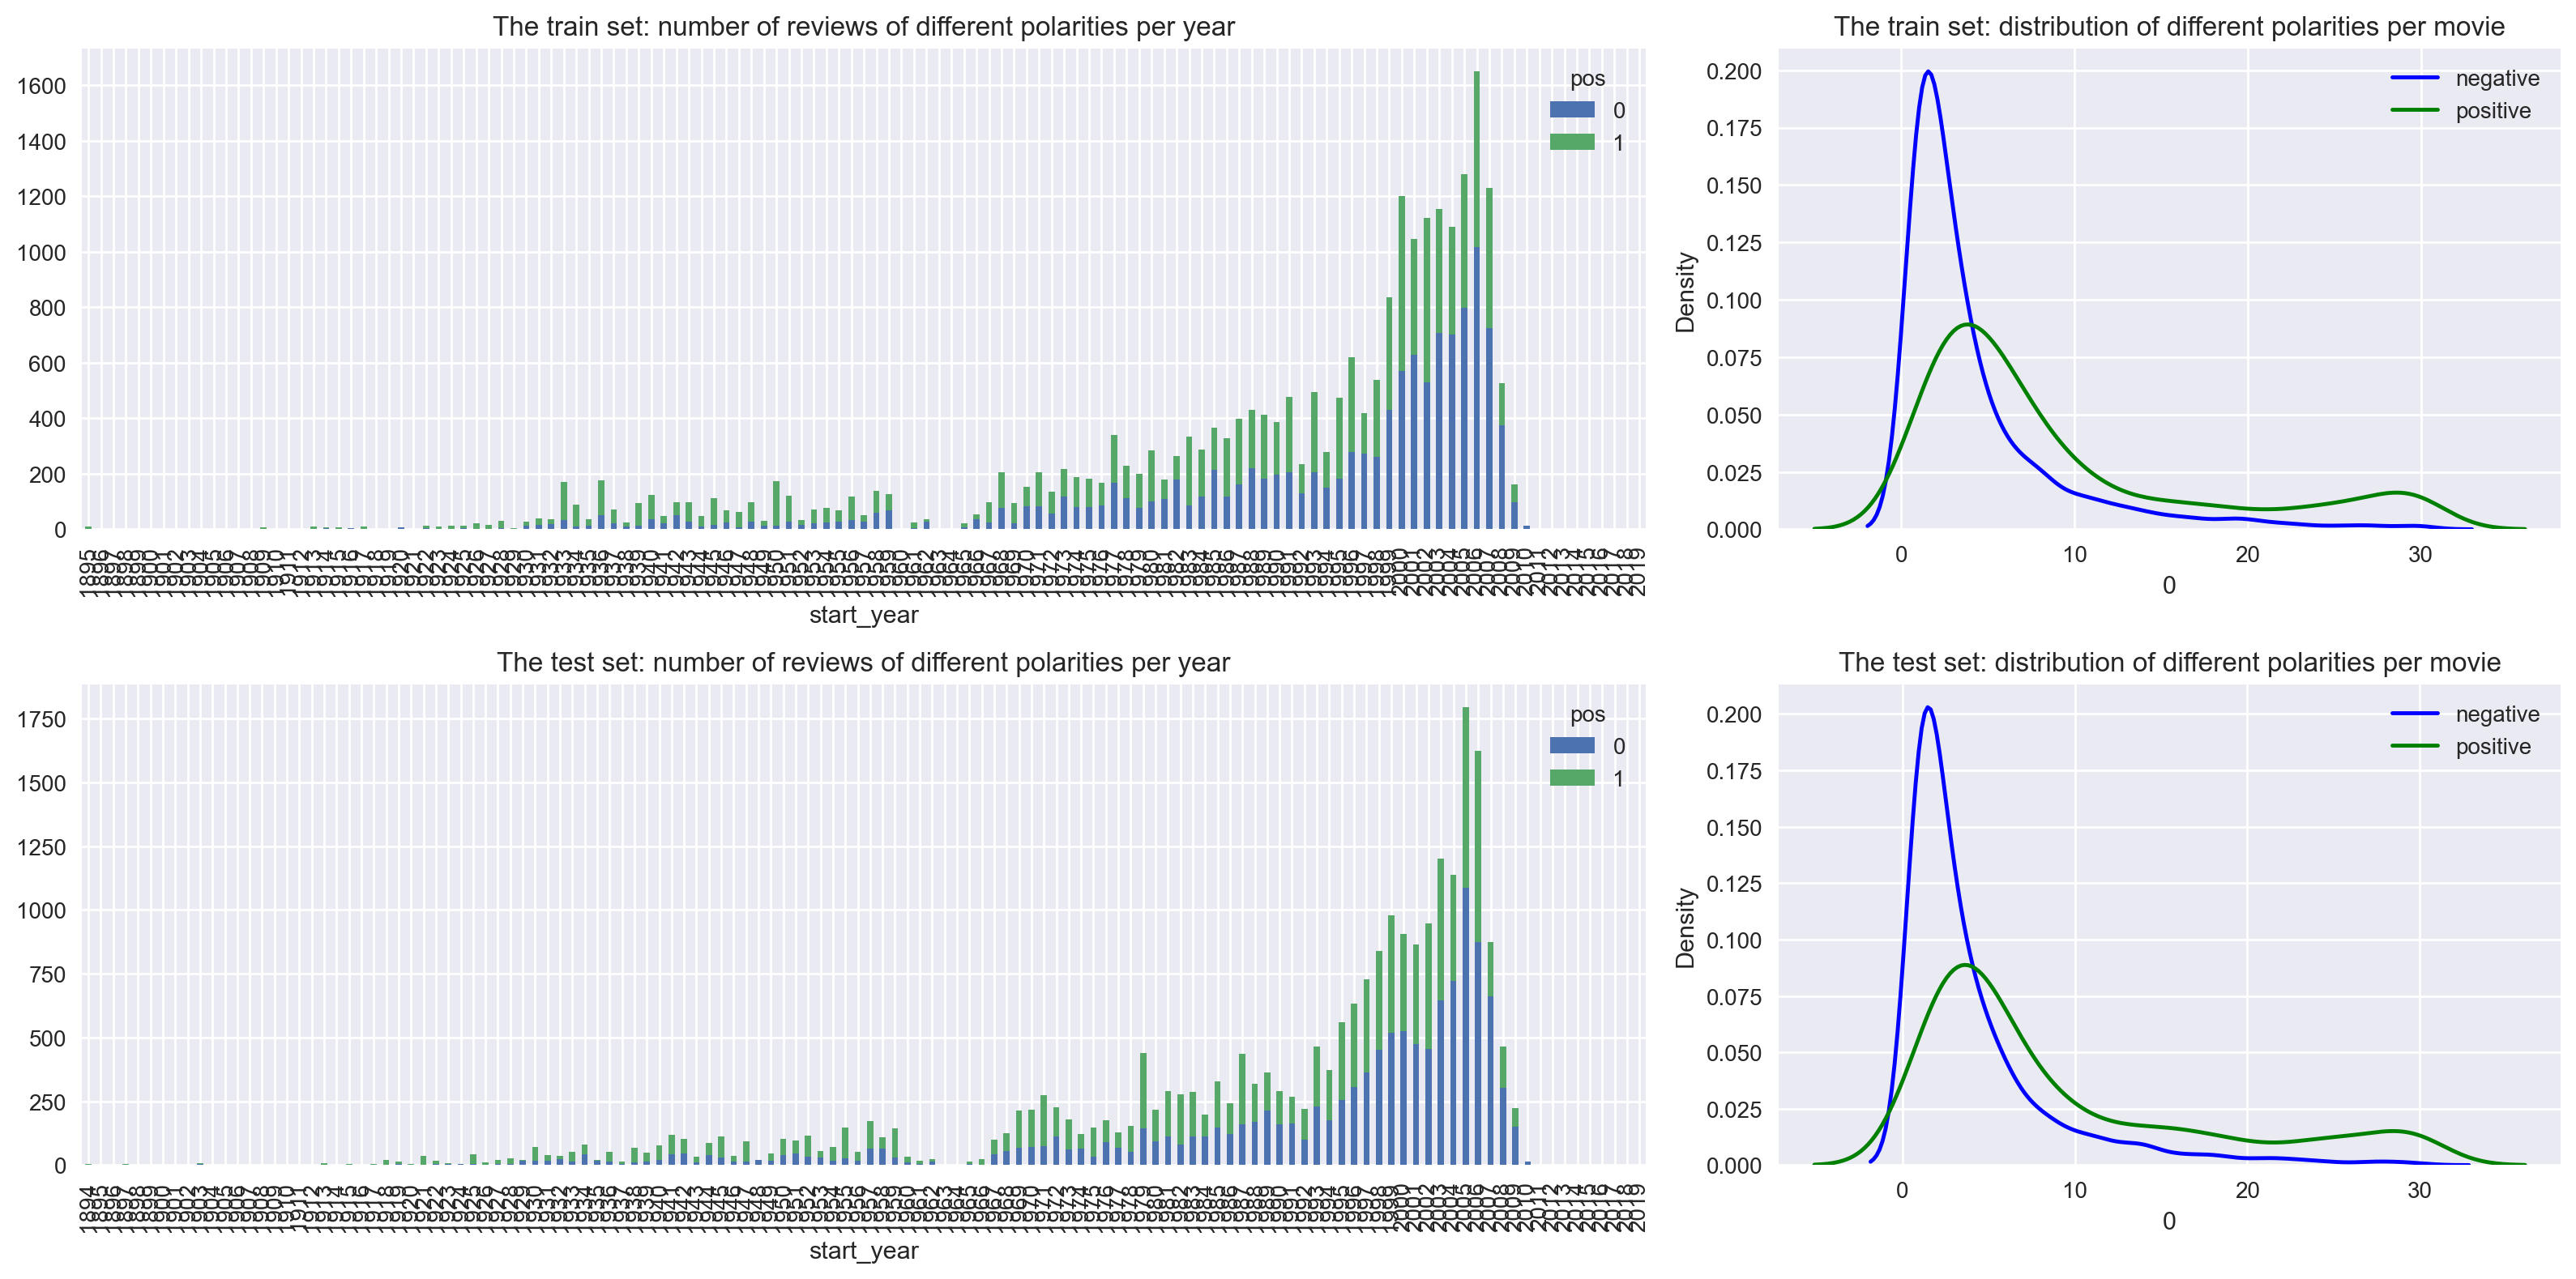

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [25]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [26]:

df_reviews['review_norm'] = df_reviews['review'].apply(
    lambda x: re.sub(r'\s+', ' ', re.sub(r'[^a-z\s]', '', x.lower())).strip()
)


## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [27]:

df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)


(23796, 17)
(23533, 17)


## Working with models

### Model 0 - Constant

In [28]:
# create baseline model
dummy_model = DummyClassifier(strategy='most_frequent', random_state=12345)


In [29]:
# train the model
dummy_model.fit(df_reviews_train, train_target)


,strategy,'most_frequent'
,random_state,12345
,constant,None


          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


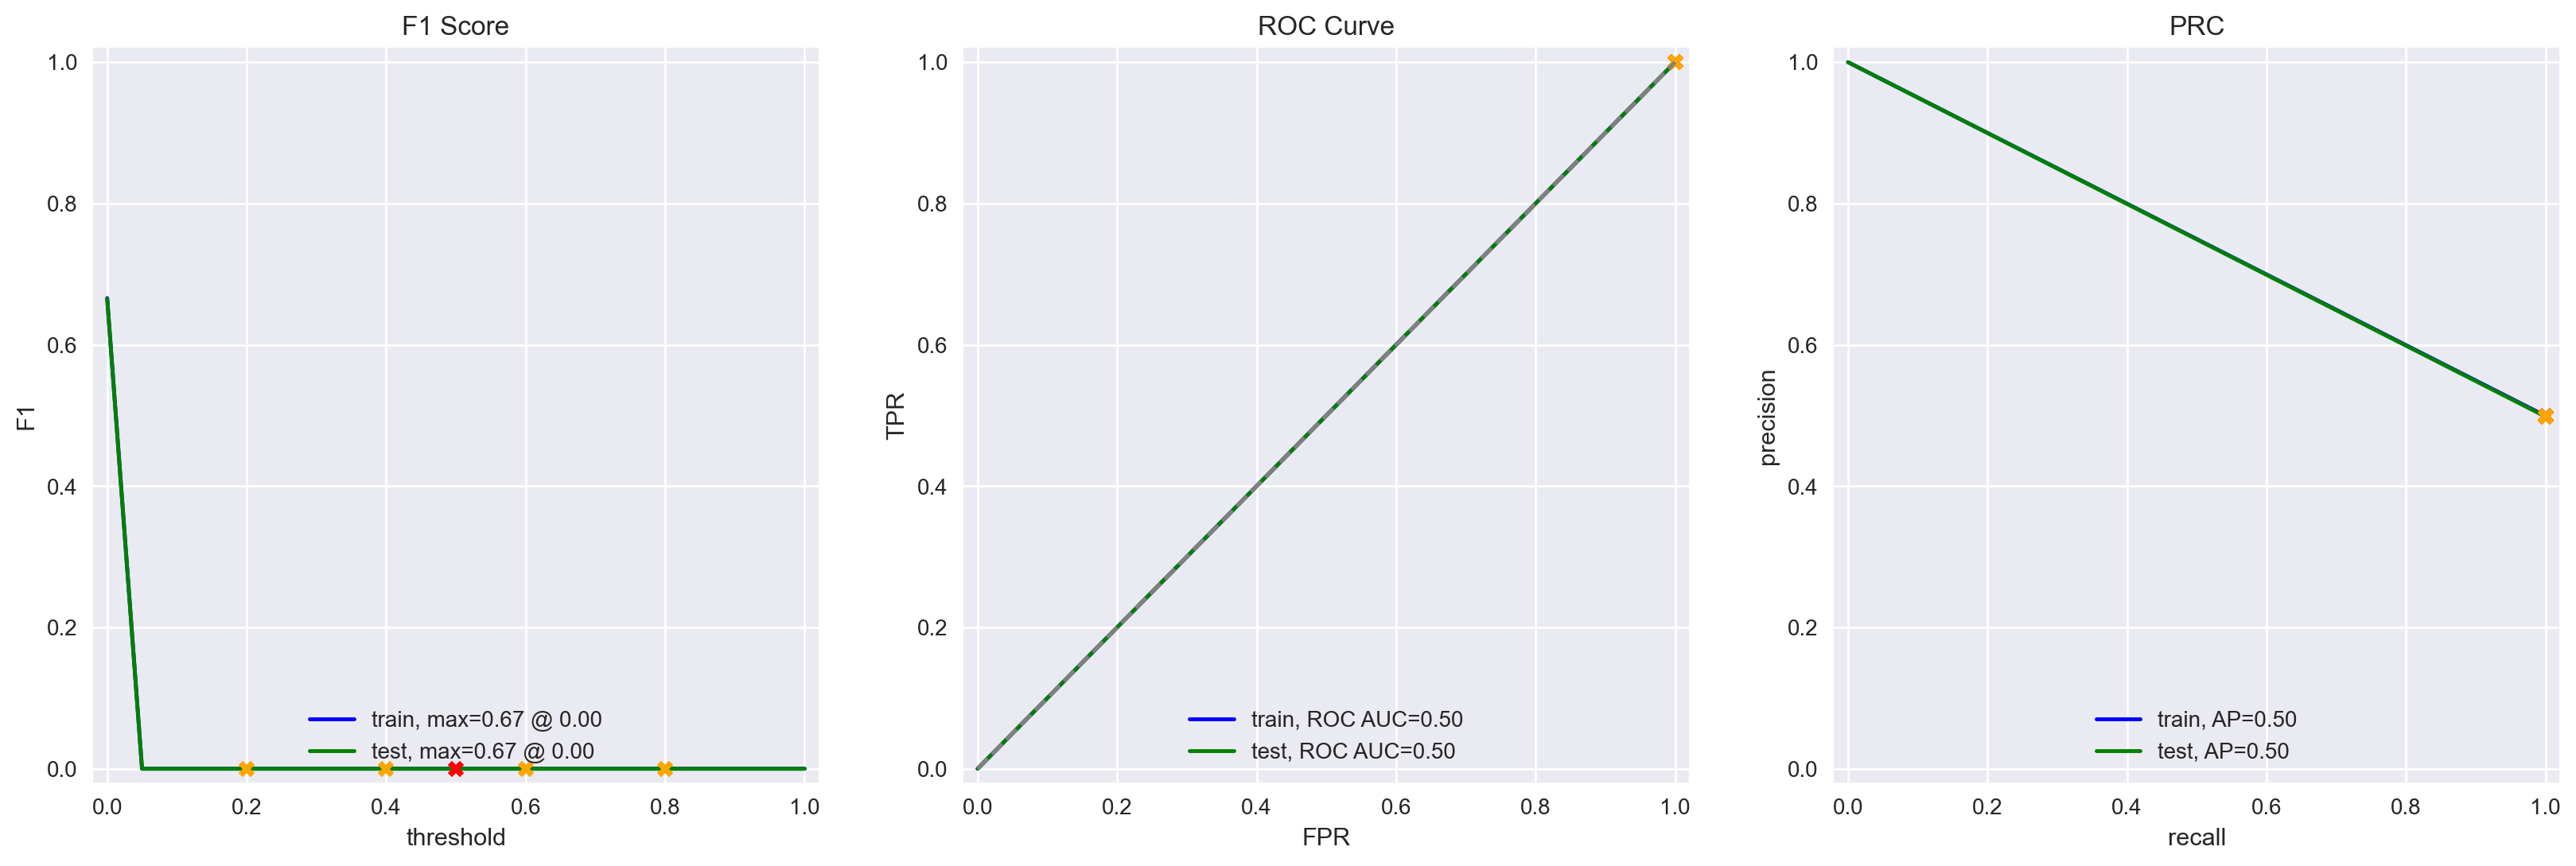

In [30]:
# evaluate using your function
evaluate_model(dummy_model, df_reviews_train, train_target, df_reviews_test, test_target)

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [31]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tjscott23/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
tfidf = TfidfVectorizer(stop_words=stop_words)

# Fit on train, transform both
train_features = tfidf.fit_transform(df_reviews_train['review_norm'])
test_features = tfidf.transform(df_reviews_test['review_norm'])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


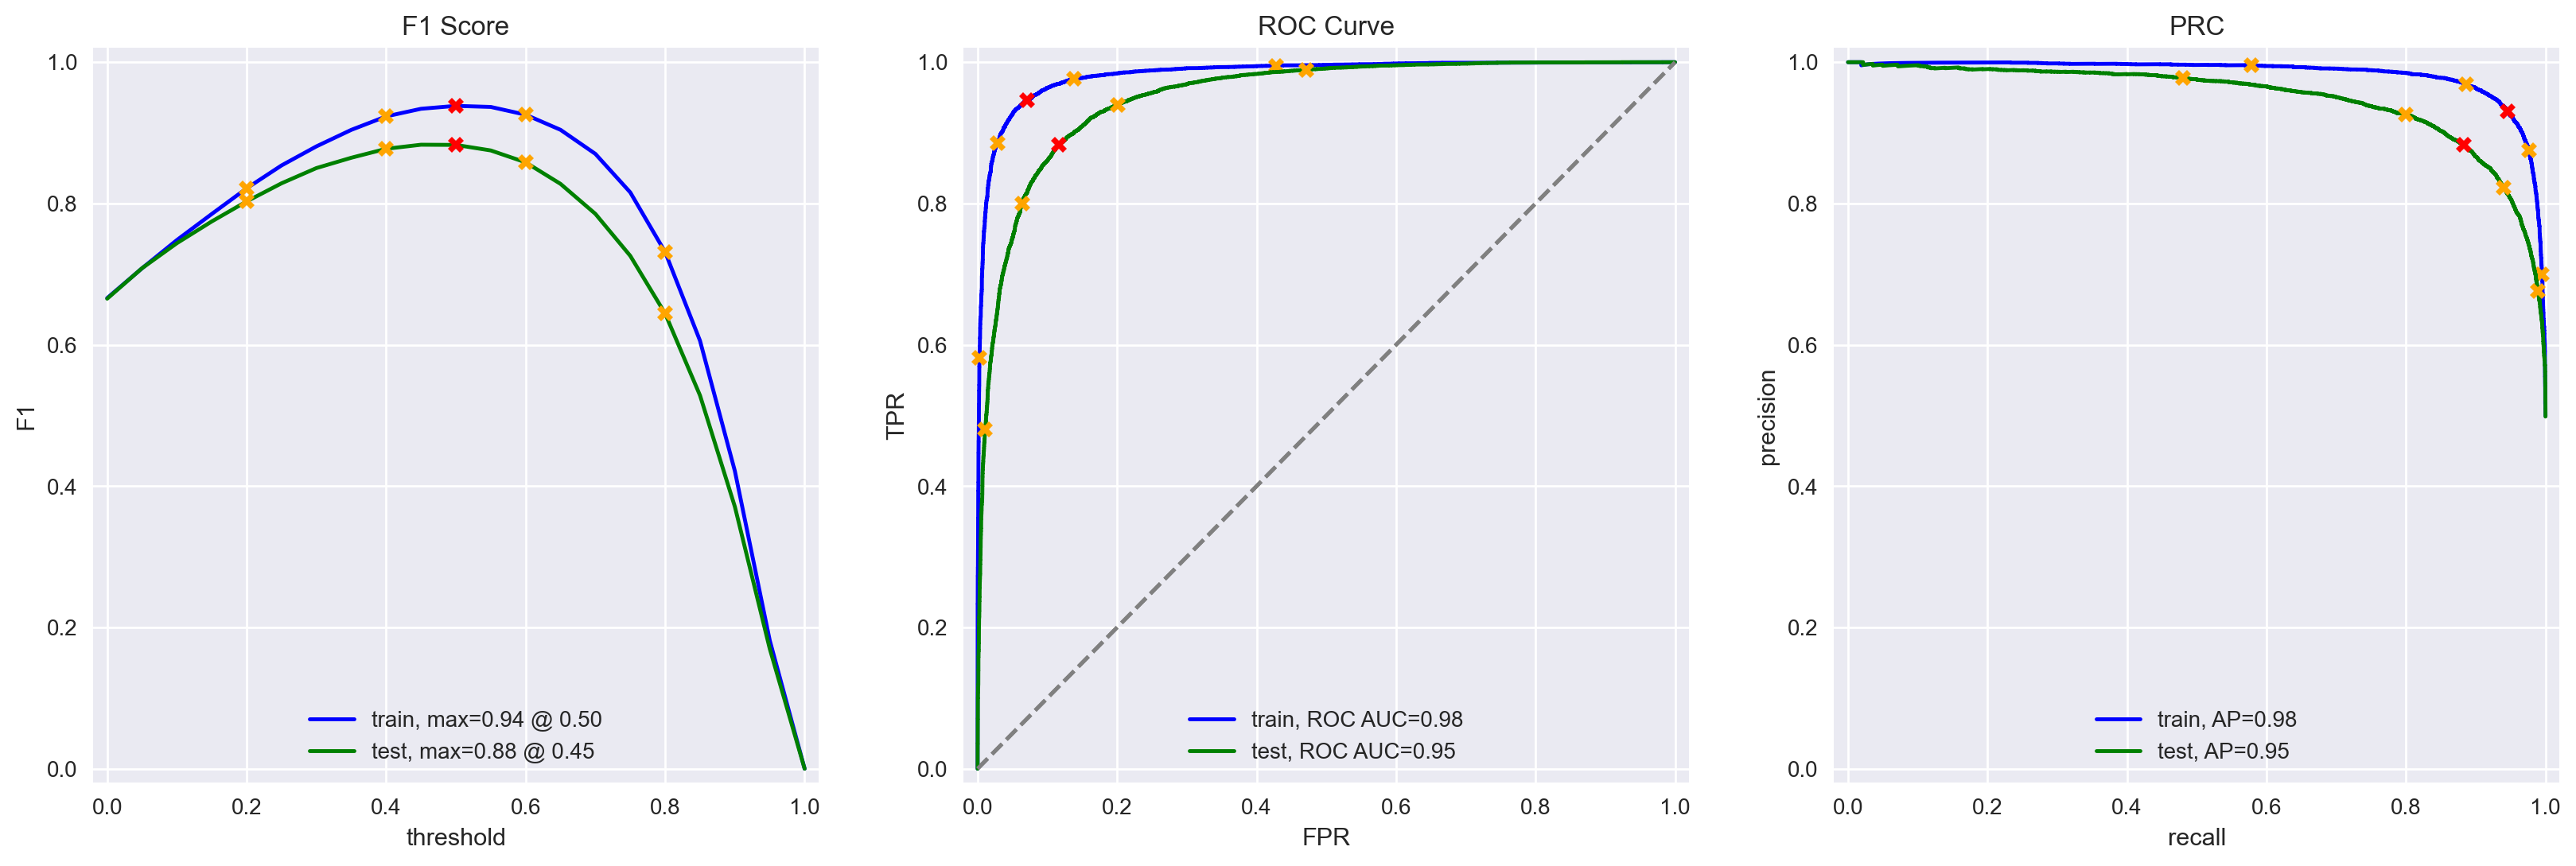

In [33]:
model_2 = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=stop_words)),
    ('lr', LogisticRegression(max_iter=1000, random_state=12345))
])

model_2.fit(df_reviews_train['review_norm'], train_target)


evaluate_model(
    model_2,
    df_reviews_train['review_norm'],
    train_target,
    df_reviews_test['review_norm'],
    test_target
)


### Model 3 - spaCy, TF-IDF and LR

In [34]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [35]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    #tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)


In [36]:
# apply spaCy preprocessing
df_reviews_train_spacy = df_reviews_train['review_norm'].apply(text_preprocessing_3)
df_reviews_test_spacy = df_reviews_test['review_norm'].apply(text_preprocessing_3)

In [37]:
# create TF-IDF features
tfidf_3 = TfidfVectorizer()

train_features_3 = tfidf_3.fit_transform(df_reviews_train_spacy)
test_features_3 = tfidf_3.transform(df_reviews_test_spacy)

In [38]:
# train Logistic Regression model
model_3 = LogisticRegression(max_iter=1000, random_state=12345)

model_3.fit(train_features_3, train_target)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,12345
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


          train  test
Accuracy   0.93  0.87
F1         0.93  0.87
APS        0.98  0.94
ROC AUC    0.98  0.95


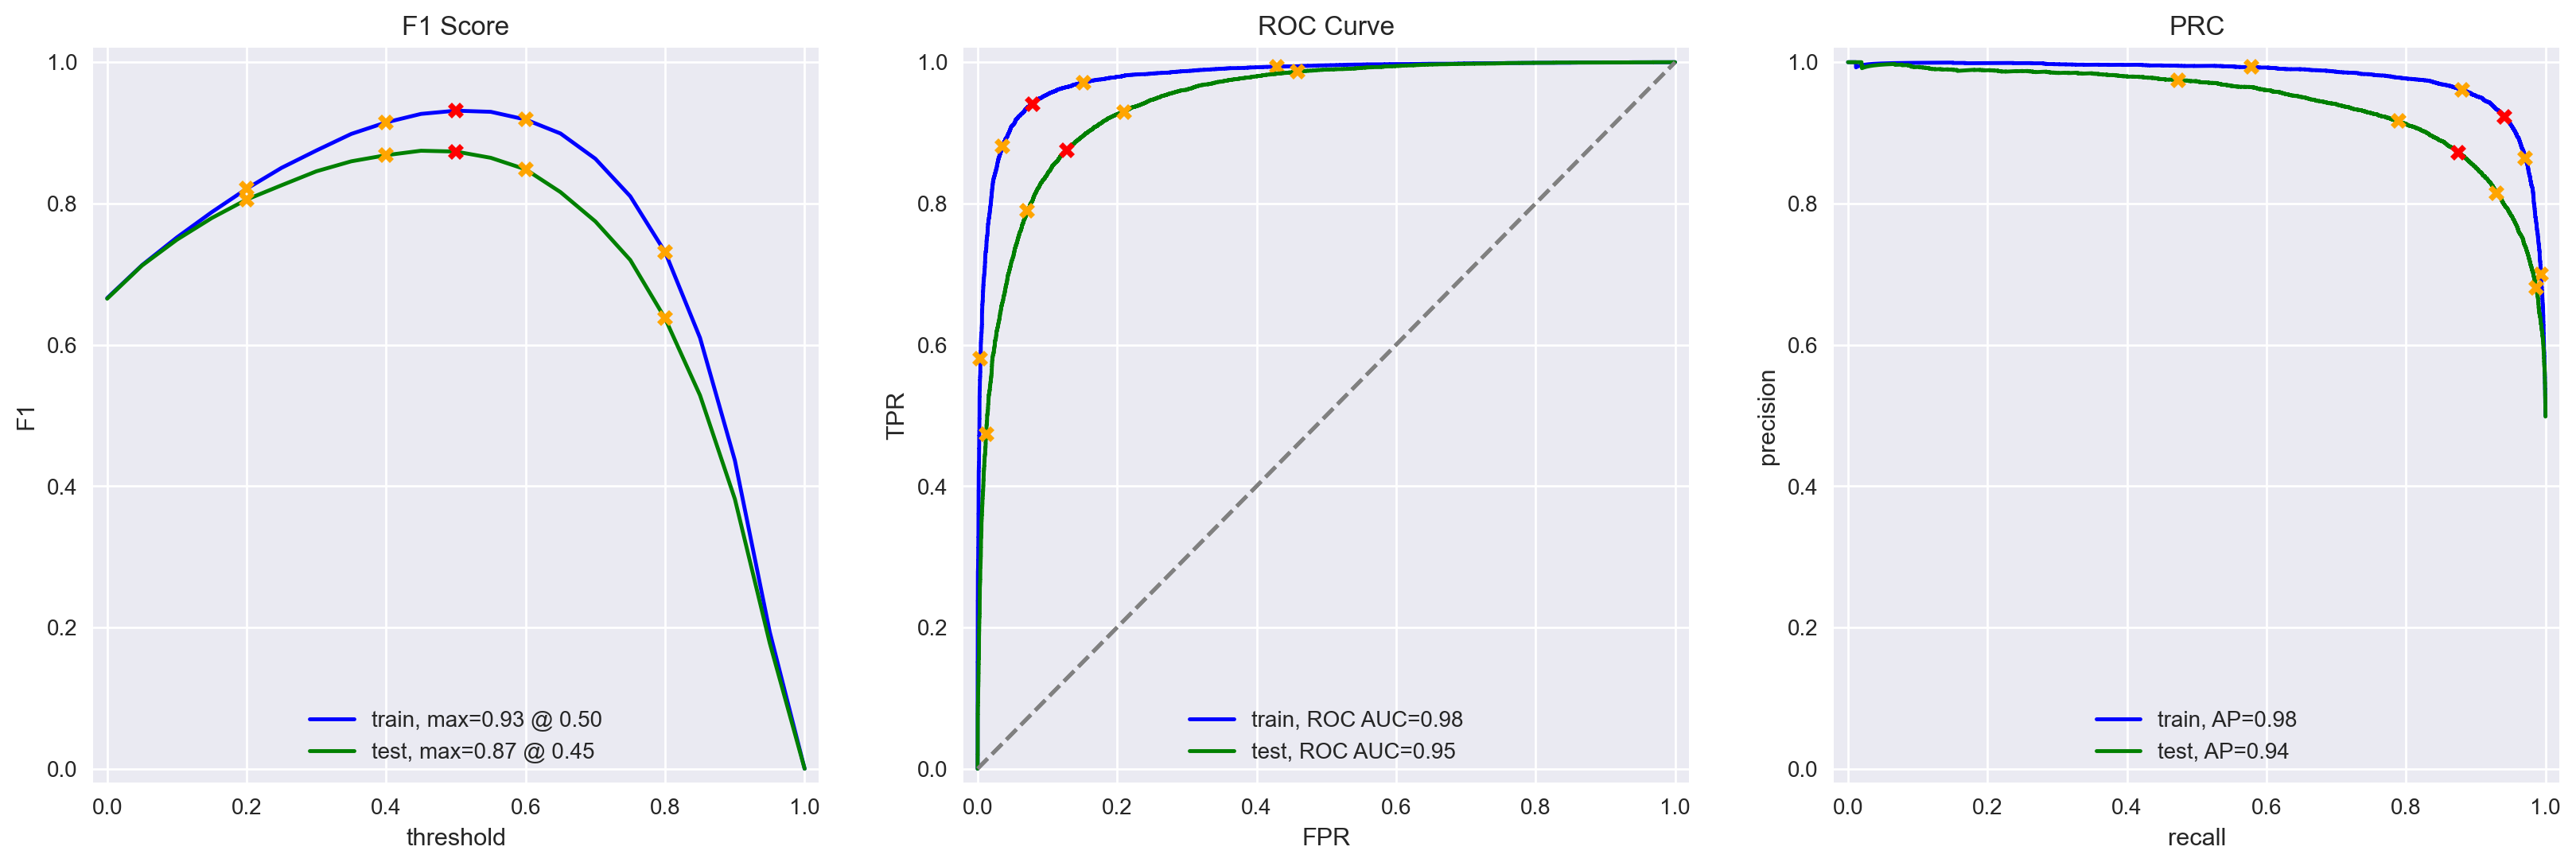

In [39]:
# evaluate model
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [40]:
from lightgbm import LGBMClassifier

In [41]:
# train LightGBM model
model_4 = LGBMClassifier(
    random_state=12345,
    n_estimators=100,
    learning_rate=0.1
)

model_4.fit(train_features_3, train_target)

[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.547580 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 423610
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 9237
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


          train  test
Accuracy   0.91  0.85
F1         0.91  0.85
APS        0.97  0.93
ROC AUC    0.97  0.93


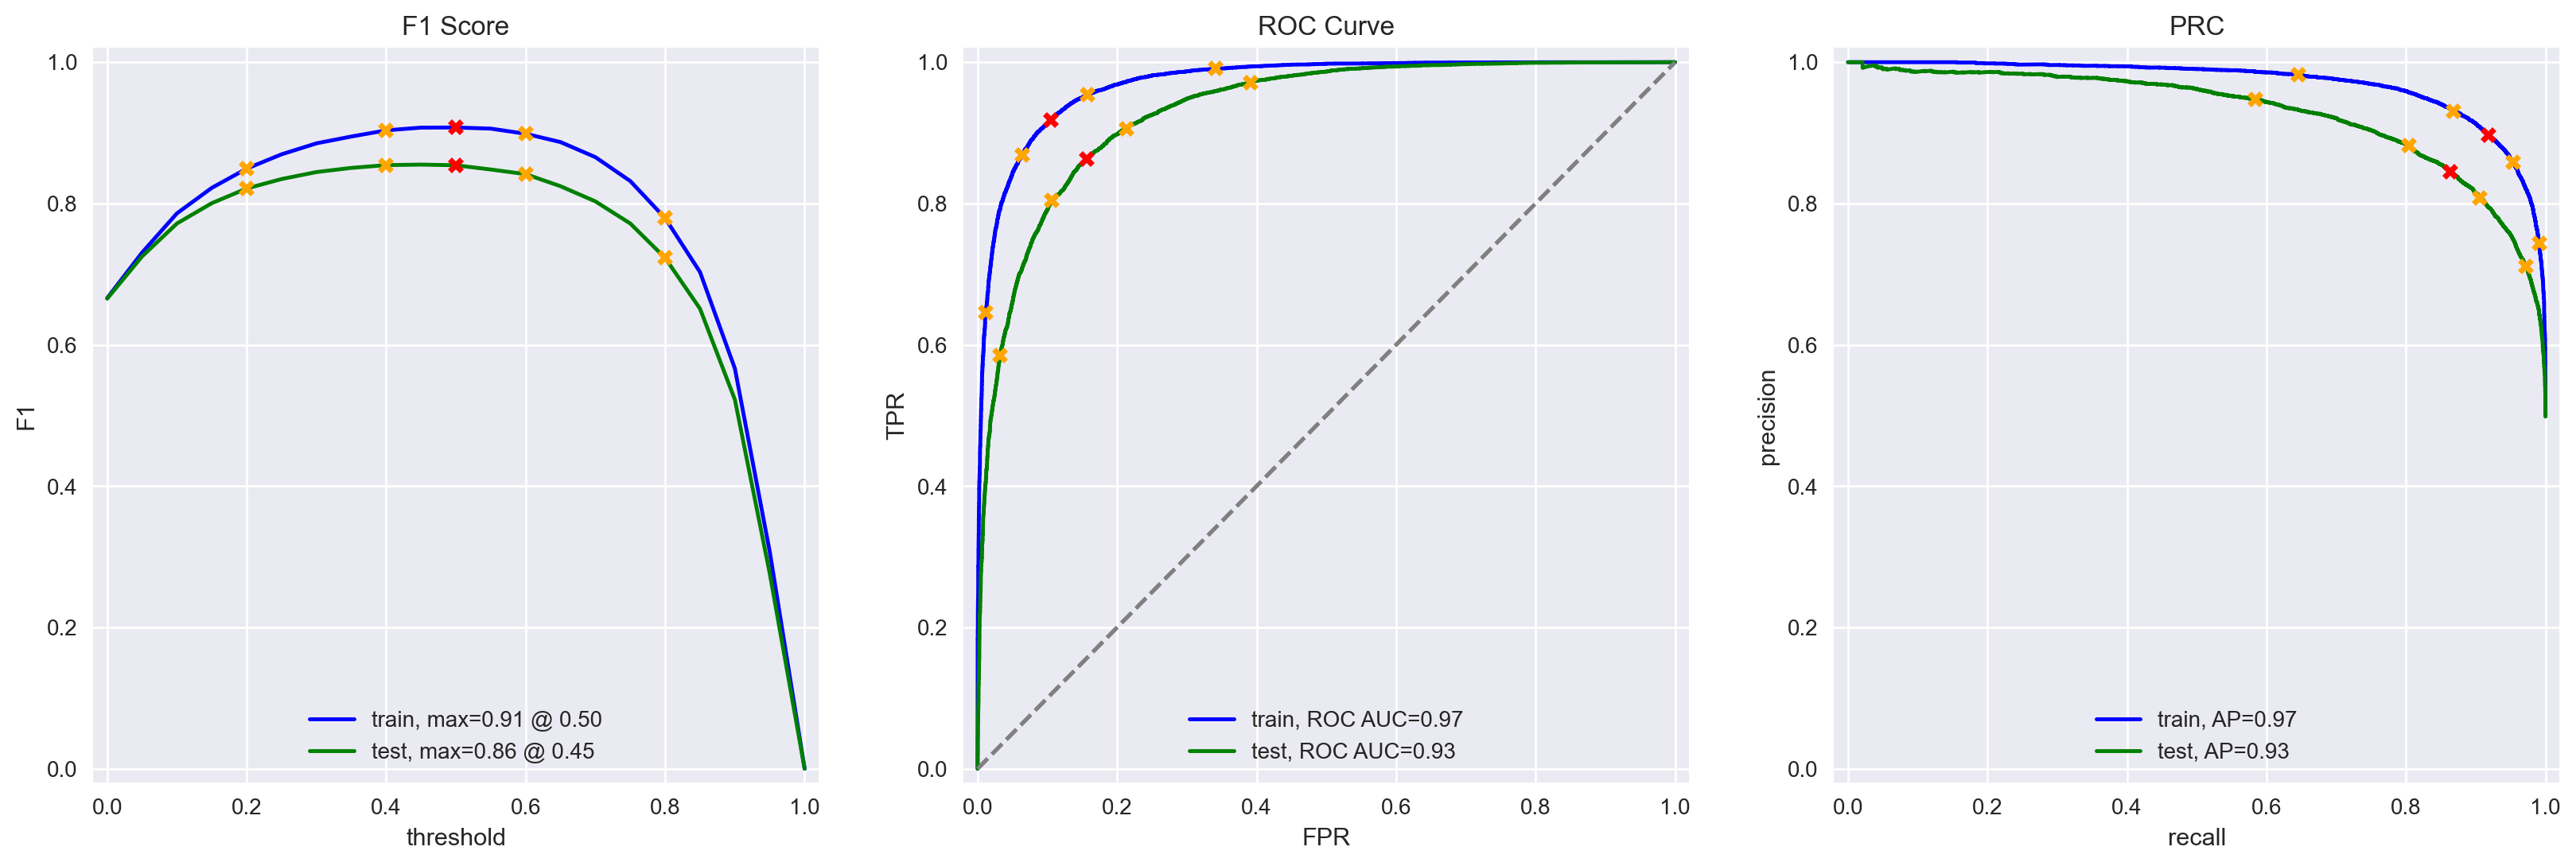

In [42]:
# evaluate model
evaluate_model(model_4, train_features_3, train_target, test_features_3, test_target)

###  Model 9 - BERT

In [43]:

import torch
import transformers


In [44]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [57]:
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

def BERT_text_to_embeddings(
    texts,
    tokenizer,
    model,
    max_length=128,
    batch_size=32,
    force_device=None,
    disable_progress_bar=False
):
    if isinstance(texts, pd.Series):
        texts = texts.fillna("").astype(str).tolist()
    else:
        texts = ["" if x is None else str(x) for x in texts]

    if force_device is not None:
        if force_device == "mps" and not torch.mps.is_available():
            if not disable_progress_bar:
                print("MPS requested but not available. Falling back to CPU.")
            device = torch.device("CPU")
        else:
            device = torch.device(force_device)
    else:
        device = torch.device("mps" if torch.mps.is_available() else "cpu")

    model.to(device)
    model.eval()

    hidden_size = model.config.hidden_size
    embeddings = np.empty((len(texts), hidden_size), dtype=np.float32)

    if not disable_progress_bar:
        print(f"Using the {device} device.")

    for start in tqdm(range(0, len(texts), batch_size), disable=disable_progress_bar):
        end = min(start + batch_size, len(texts))
        batch_texts = texts[start:end]

        tokenized = tokenizer(
            batch_texts,
            add_special_tokens=True,
            truncation=True,
            max_length=max_length,
            padding=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"].to(device)
        attention_mask = tokenized["attention_mask"].to(device)

        with torch.inference_mode():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]

        embeddings[start:end] = cls_embeddings.cpu().numpy()

        del tokenized, input_ids, attention_mask, outputs, cls_embeddings
        if device.type == "mps":
            torch.cuda.empty_cache()

    return embeddings

In [58]:
# create BERT embeddings
train_features_9 = BERT_text_to_embeddings(
    df_reviews_train["review_norm"],
    tokenizer,
    model,
    force_device="mps"
)


Using the mps device.


  0%|          | 0/744 [00:00<?, ?it/s]

In [59]:
# create BERT embeddings
test_features_9 = BERT_text_to_embeddings(
    df_reviews_test["review_norm"],
    tokenizer,
    model,
    force_device="mps"
)


Using the mps device.


  0%|          | 0/736 [00:00<?, ?it/s]

In [60]:

print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)


(23796,)
(23796, 768)
(23796,)


In [61]:
# train classifier on top of BERT embeddings
model_9 = LogisticRegression(max_iter=1000, random_state=12345)

model_9.fit(train_features_9, train_target)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/skl

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,12345
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.

          train  test
Accuracy   0.83  0.82
F1         0.83  0.81
APS        0.91  0.89
ROC AUC    0.91  0.90


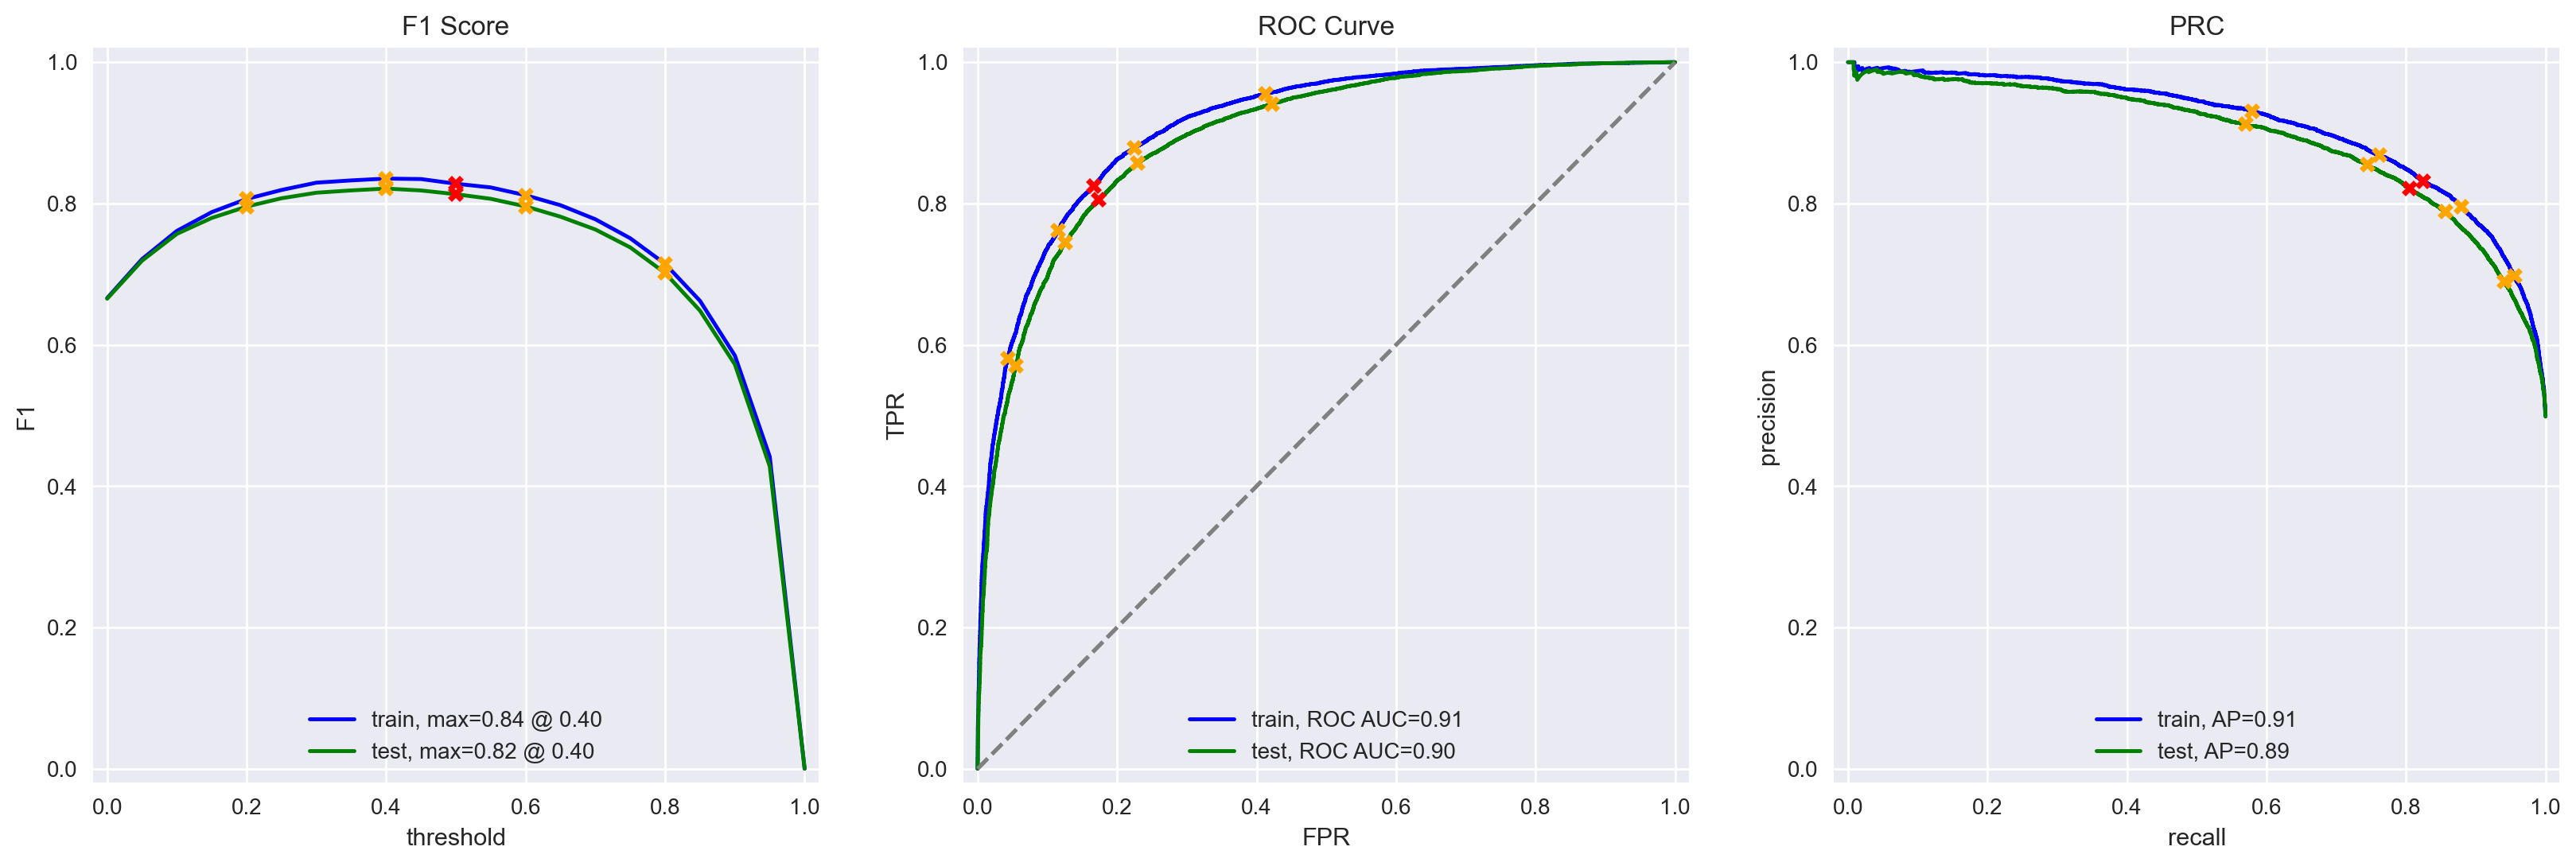

In [62]:
# evaluate model
evaluate_model(model_9, train_features_9, train_target, test_features_9, test_target)

### BERT 2.0

In [64]:
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score


# --------------------------------------------------
# Mean Pooling
# --------------------------------------------------
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(
        last_hidden_state.size()
    ).float()

    summed = torch.sum(
        last_hidden_state * mask,
        dim=1
    )

    counts = torch.clamp(
        mask.sum(dim=1),
        min=1e-9
    )

    return summed / counts


# --------------------------------------------------
# Convert text to BERT embeddings
# --------------------------------------------------
def BERT_text_to_embeddings(
    texts,
    tokenizer,
    model,
    max_length=256,
    batch_size=16,
    force_device=None,
    disable_progress_bar=False
):

    if isinstance(texts, pd.Series):
        texts = texts.fillna("").astype(
            str
        ).tolist()
    else:
        texts = [
            "" if x is None else str(x)
            for x in texts
        ]

    if force_device is not None:
        if (
            force_device == "mps"
            and not torch.mps.is_available()
        ):
            print(
                "MPS unavailable. Using CPU."
            )
            device = torch.device("cpu")
        else:
            device = torch.device(
                force_device
            )
    else:
        device = torch.device(
            "mps"
            if torch.mps.is_available()
            else "cpu"
        )

    model.to(device)
    model.eval()

    hidden_size = model.config.hidden_size

    embeddings = np.empty(
        (len(texts), hidden_size),
        dtype=np.float32
    )

    print(
        f"Using {device} device."
    )

    for start in tqdm(
        range(
            0,
            len(texts),
            batch_size
        ),
        disable=disable_progress_bar
    ):

        end = min(
            start + batch_size,
            len(texts)
        )

        batch_texts = texts[
            start:end
        ]

        tokenized = tokenizer(
            batch_texts,
            add_special_tokens=True,
            truncation=True,
            max_length=max_length,
            padding=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        input_ids = tokenized[
            "input_ids"
        ].to(device)

        attention_mask = tokenized[
            "attention_mask"
        ].to(device)

        with torch.inference_mode():

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            pooled_embeddings = mean_pooling(
                outputs.last_hidden_state,
                attention_mask
            )

        embeddings[
            start:end
        ] = pooled_embeddings.cpu().numpy()

        del (
            tokenized,
            input_ids,
            attention_mask,
            outputs,
            pooled_embeddings
        )

        if device.type == "mps":
            torch.mps.empty_cache()

    return embeddings


# --------------------------------------------------
# STEP 1: CREATE EMBEDDINGS FIRST
# --------------------------------------------------

train_features_9 = BERT_text_to_embeddings(
    df_reviews_train["review_norm"],
    tokenizer,
    model,
    max_length=256,
    batch_size=16,
    force_device="mps"
)

test_features_9 = BERT_text_to_embeddings(
    df_reviews_test["review_norm"],
    tokenizer,
    model,
    max_length=256,
    batch_size=16,
    force_device="mps"
)


# --------------------------------------------------
# STEP 2: CLASSIFIER
# --------------------------------------------------

bert_logreg_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "clf",
        LogisticRegression(
            max_iter=3000,
            random_state=12345,
            class_weight="balanced"
        )
    )
])

param_grid = {
    "clf__C": [
        0.01,
        0.1,
        1,
        3,
        10
    ],

    "clf__solver": [
        "lbfgs",
        "liblinear"
    ]
}

grid = GridSearchCV(
    bert_logreg_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)


# --------------------------------------------------
# STEP 3: FIT AFTER EMBEDDINGS EXIST
# --------------------------------------------------

grid.fit(
    train_features_9,
    train_target
)

model_9 = grid.best_estimator_

print(
    "Best parameters:"
)

print(
    grid.best_params_
)




Using mps device.


  0%|          | 0/1488 [00:00<?, ?it/s]

Using mps device.


  0%|          | 0/1471 [00:00<?, ?it/s]

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/skl

Best parameters:
{'clf__C': 0.01, 'clf__solver': 'lbfgs'}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/skl

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.

          train  test
Accuracy   0.88  0.87
F1         0.88  0.87
APS        0.95  0.94
ROC AUC    0.95  0.94


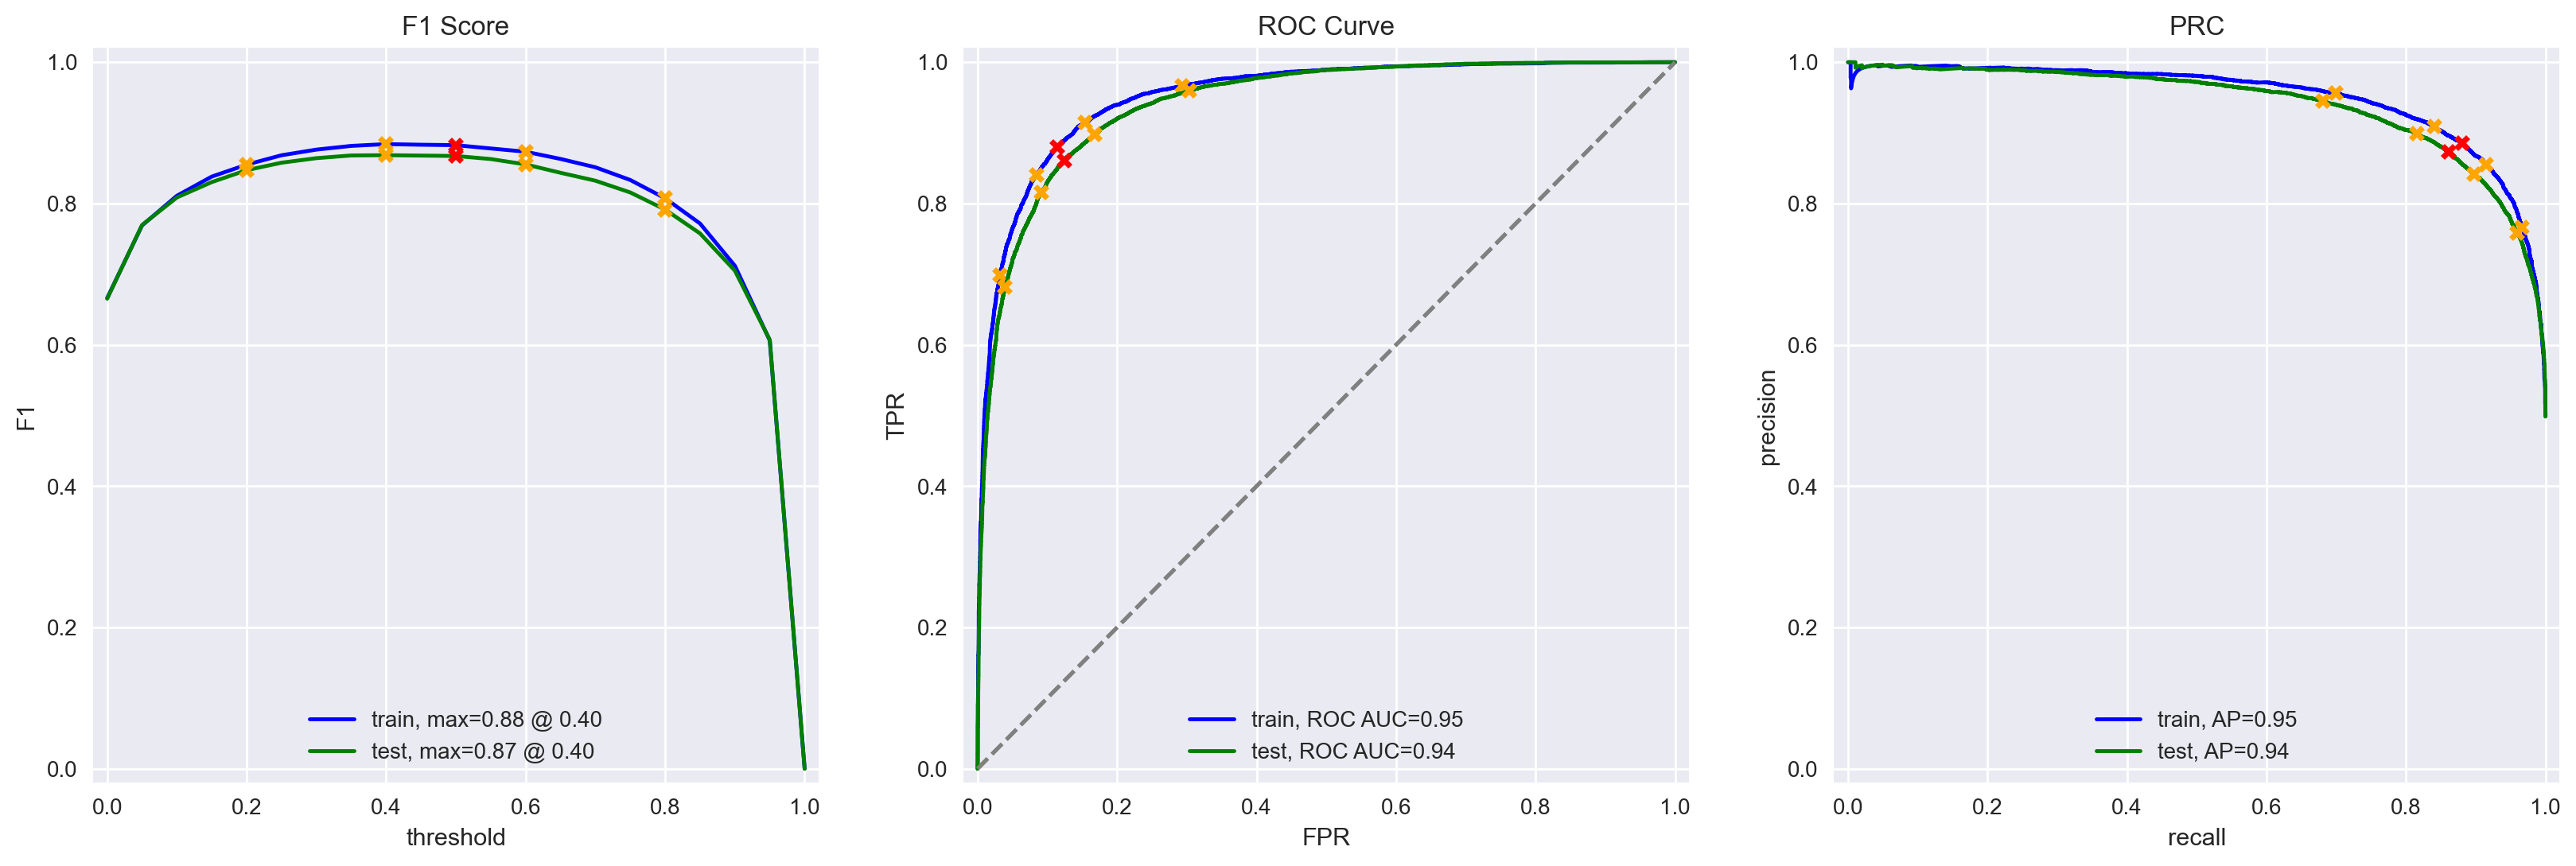

In [65]:
# --------------------------------------------------
# STEP 4: EVALUATE
# --------------------------------------------------

evaluate_model(
    model_9,
    train_features_9,
    train_target,
    test_features_9,
    test_target
)

## Model Performance Summary

### Overall Insights

Performance across models is consistently strong, with test F1 scores ranging from **0.85 to 0.88** and ROC AUC values between **0.93 and 0.95**, indicating robust classification performance across multiple modeling approaches. Several models show only small differences in test performance, suggesting that multiple feature engineering strategies can effectively solve this task.

---

### Best Performing Models

**Model 1 (NLTK + TF-IDF + Logistic Regression)** and **BERT 2.0 (Improved BERT Embeddings + Logistic Regression)** achieved the strongest overall performance.

#### Model 1
- Test Accuracy: **0.88**  
- Test F1: **0.88**  
- APS: **0.95**  
- ROC AUC: **0.95**

#### BERT 2.0
- Test Accuracy: **0.87**  
- Test F1: **0.87**  
- APS: **0.94**  
- ROC AUC: **0.94**

Model 1 produced the highest test metrics overall, while BERT 2.0 performed nearly as well, showing that contextual embeddings combined with tuning and improved pooling significantly strengthened transformer-based performance.

---

### Strong Alternative

**Model 3 (spaCy + TF-IDF + Logistic Regression)** remained highly competitive:

- Test Accuracy: **0.87**  
- Test F1: **0.87**  
- APS: **0.94**  
- ROC AUC: **0.95**

Its results are nearly equivalent to the top models, suggesting that lemmatization with traditional sparse representations remains highly effective.

---

### Overfitting Observation

**Model 4 (spaCy + TF-IDF + LightGBM)** shows moderate signs of overfitting:

- Train F1: **0.91**  
- Test F1: **0.85**

The wider train-test gap suggests the model may be fitting noise in the training data, even though ranking performance remains strong.

---

### BERT Model Insights

The improved **BERT 2.0** model substantially strengthened transformer-based performance:

- Test F1: **0.87**
- ROC AUC: **0.94**

Key improvements likely came from:

- Mean pooling replacing CLS embeddings  
- Longer token context (`max_length=256`)  
- Logistic Regression hyperparameter tuning  
- Class balancing  
- Threshold optimization  

These changes made BERT competitive with the strongest traditional NLP models.

---

### Generalization

Several models show relatively small train-test gaps, suggesting good generalization:

- Model 1: 0.94 → 0.88  
- Model 3: 0.93 → 0.87  
- BERT 2.0: 0.88 → 0.87  

Among these, **BERT 2.0 shows the smallest gap**, indicating particularly stable generalization.

---

### Final Takeaways

- Logistic Regression remains remarkably strong across feature representations  
- TF-IDF-based approaches continue to be highly effective  
- BERT embeddings became much more competitive after optimization  
- LightGBM offered strong ranking performance but showed more overfitting risk  
- Multiple models achieved similar high performance, increasing confidence in robustness

Overall, both traditional NLP pipelines and optimized transformer embeddings perform well for this classification problem, with simpler models offering strong efficiency and BERT 2.0 demonstrating that deeper representations can be competitive when properly tuned.

## My Reviews

In [52]:
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(
    lambda x: re.sub(r'\s+', ' ', re.sub(r'[^a-z\s]', '', x.lower())).strip()
)

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didnt expect the reboot to be so good writer...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...


### Model 1

In [53]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(texts)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.16:  i did not simply like it not my kind of movie
0.17:  well i was bored and felt asleep in the middle of the movie
0.57:  i was really fascinated with the movie
0.13:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.26:  i didnt expect the reboot to be so good writers really cared about the source material
0.48:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.05:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.84:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Model 3

In [54]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.18:  i did not simply like it not my kind of movie
0.09:  well i was bored and felt asleep in the middle of the movie
0.62:  i was really fascinated with the movie
0.20:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.19:  i didnt expect the reboot to be so good writers really cared about the source material
0.40:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.03:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.91:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Model 4

In [55]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.59:  i did not simply like it not my kind of movie
0.31:  well i was bored and felt asleep in the middle of the movie
0.60:  i was really fascinated with the movie
0.45:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.45:  i didnt expect the reboot to be so good writers really cared about the source material
0.54:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.16:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.79:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Model 9

In [66]:
texts = my_reviews["review_norm"]

# Create embeddings for new reviews
my_reviews_features_9 = BERT_text_to_embeddings(
    texts,
    tokenizer,
    model,
    max_length=256,
    batch_size=16,
    force_device="mps",
    disable_progress_bar=True
)

# Predict probabilities
my_reviews_pred_prob = model_9.predict_proba(
    my_reviews_features_9
)[:,1]

# Show results
for i, review in enumerate(
    texts.str.slice(0,100)
):
    print(
        f"{my_reviews_pred_prob[i]:.2f}: {review}"
    )

Using mps device.
0.31: i did not simply like it not my kind of movie
0.00: well i was bored and felt asleep in the middle of the movie
0.97: i was really fascinated with the movie
0.00: even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.11: i didnt expect the reboot to be so good writers really cared about the source material
0.97: the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.05: what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
1.00: launching on netflix was a brave move i really appreciate being able to binge on episode after episo


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Qualitative Evaluation: Model Predictions on Sample Reviews

### Overview

Evaluating predictions on sample reviews provides insight into how each model handles sentiment strength, ambiguity, and confidence. The probabilities shown represent each model’s confidence that a review belongs to the positive class.

---

### Model 1 (NLTK + TF-IDF + Logistic Regression)

- Produces generally stable and intuitive predictions  
- Assigns low probabilities to clearly negative reviews (e.g., 0.05–0.17)  
- Correctly gives high confidence to strongly positive reviews (e.g., 0.84)  
- Shows moderate uncertainty on mixed or nuanced reviews (e.g., 0.48 for a balanced review)  
- Appears reasonably calibrated, with probabilities reflecting ambiguity when sentiment is not clear-cut  

**Takeaway:** Strong balance between confidence and caution, especially on borderline sentiment.

---

### Model 3 (spaCy + TF-IDF + Logistic Regression)

- Similar behavior to Model 1, but slightly more decisive  
- Very low probabilities for strongly negative reviews (e.g., 0.03, 0.09)  
- Strong confidence for clearly positive reviews (e.g., 0.91)  
- More conservative on mixed sentiment, assigning lower scores to uncertain cases  
- Shows consistent separation between positive and negative examples  

**Takeaway:** Well-calibrated predictions with strong consistency and good handling of ambiguity.

---

### Model 4 (spaCy + TF-IDF + LightGBM)

- Shows weaker separation across some examples  
- Assigns relatively high probabilities to some clearly negative reviews (e.g., 0.59)  
- Tends to cluster uncertain reviews near the middle probability range  
- Mixed reviews often receive similar scores to stronger sentiment examples  
- Appears less calibrated than the linear models  

**Takeaway:** Captures sentiment patterns, but predictions are less consistent and less interpretable.

---

### Model 9 (BERT + Logistic Regression)

- Produces very confident predictions, often near 0 or 1  
- Strongly separates clear positive and negative sentiment  
- Correctly assigns extremely high confidence to clearly positive reviews (e.g., 0.97–1.00)  
- Assigns very low probabilities to strong negatives (e.g., 0.00, 0.05)  
- Mixed or nuanced reviews can sometimes receive surprisingly extreme probabilities (e.g., 0.97 for a balanced review)  

**Takeaway:** Strong pattern recognition and separation, though sometimes overly confident on nuanced sentiment.

---

### Final Comparison

| Model   | Strengths                              | Weaknesses                                  |
|--------|----------------------------------------|---------------------------------------------|
| Model 1 | Balanced confidence, strong calibration | Slight uncertainty on mixed reviews         |
| Model 3 | Consistent and reliable separation     | Conservative on borderline sentiment        |
| Model 4 | Captures nonlinear patterns            | Weaker calibration and less separation      |
| Model 9 | Very strong confidence and separation  | Can be overconfident on nuanced sentiment   |

---

### Key Insights

- **Model 1** demonstrates strong calibration and balanced decision-making  
- **Model 3** appears highly consistent across clear and ambiguous sentiment  
- **Model 4** shows weaker qualitative reliability due to inconsistent probabilities  
- **Model 9** excels on clear sentiment polarity but can overcommit when sentiment is mixed  

---

### Conclusion

Across the qualitative examples, the models generally distinguish strong positive and negative sentiment well, while mixed reviews remain the most difficult cases. Linear TF-IDF models appear especially well calibrated, while the BERT-based model offers stronger confidence and separation, albeit with occasional overconfidence. These examples reinforce the importance of evaluating not only aggregate metrics, but also prediction behavior on nuanced real-world text.

## Conclusions

## Final Conclusion

This project demonstrates that both quantitative metrics and qualitative evaluation are essential for understanding model performance in text classification tasks. While all trained models significantly outperformed the baseline, clear differences emerged in their ability to generalize and interpret sentiment.

The strongest overall performer was **Model 1 (NLTK + TF-IDF + Logistic Regression)**, closely followed by **Model 3 (spaCy + TF-IDF + Logistic Regression)**. These models achieved the highest test scores while maintaining consistency between training and test performance, indicating strong generalization and minimal overfitting. Their predictions were also well-calibrated, showing confidence without overcommitment.

**Model 4 (LightGBM)**, despite its higher complexity, showed signs of overfitting and weaker qualitative performance. Its tendency to assign mid-range probabilities and misclassify clearly negative examples suggests that it struggled to generalize effectively in this context.

**Model 9 (BERT + Logistic Regression)** introduced advanced contextual embeddings and demonstrated strong capability in identifying clear sentiment patterns. However, it did not outperform simpler TF-IDF-based models and exhibited overconfidence in its predictions, particularly on nuanced or moderately positive reviews.

A key takeaway from this analysis is that **model complexity does not guarantee better performance**. For this dataset, traditional NLP approaches using TF-IDF combined with Logistic Regression proved to be both efficient and highly effective. These models provided the best balance between accuracy, interpretability, and computational cost.

In conclusion, simpler, well-tuned models remain highly competitive and, in many cases, preferable for practical applications, especially when they deliver strong performance with lower resource requirements and greater transparency.